# Best Model Pipeline — v7

> **LightGBM · 62 Features · Multi-Class Target Encoding · SHAP Explainability**
>
> Final Score: **0.4875** · Macro F1 = 0.5577 · Latency = 1.18 s · Size = 1.86 MB

---

### Rubric Coverage

| Category | Weight | Sections |
| --- | ---: | --- |
| **Model Performance** | **60** | §5 Resampling → §8 Final Model |
| Feature Engineering | 20 | §3 Encoding Maps, §4 Feature Matrix |
| Final Score | 30 | §13 Validate, §14 Score Estimate |
| **Explainability** | **10** | §8.5 SHAP, Permutation, Partial Dependence |
| **Technical Report** | **10** | `technical_report.ipynb` + SOLUTION.md |

---

### v2 → v7 Improvement Summary

| Change | Detail | Delta |
| --- | --- | --- |
| Multi-class broker/region encoding | 10 P(class=k\|category) features × 2 | +0.008 OOF F1 |
| `class_weight=None` | Let SMOTE handle imbalance alone | +0.022 OOF F1 |
| Tuned hyperparameters | `num_leaves=95, lr=0.07, ra=0.1, rl=0.5` | +0.013 OOF F1 |
| 3-step resampling | ROS→200, SMOTE→600 (C8/C9); SMOTE→3000 (C0/C5/C6) | baseline |
| Full-train encoding fix | Consistent encoding maps train↔inference | +0.004 actual F1 |

| Metric | v2 | **v7** |
| --- | --- | --- |
| Features | 44 | **62** |
| OOF F1 | 0.5977 | **0.6418** |
| Actual F1 | 0.5176 | **0.5577** |
| Score | 0.4583 | **0.4875** |

## 1. Imports & Paths

In [10]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import joblib, os, zipfile, shutil, time
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE, RandomOverSampler
import warnings; warnings.filterwarnings('ignore')

SEED      = 42
SMOOTHING = 300
N_CLASSES = 10
N_TREES   = 75
DATA_DIR  = '../Data'
SUB_DIR   = '../submission_v7'
os.makedirs(SUB_DIR, exist_ok=True)

TARGET = 'Purchased_Coverage_Bundle'

print('LightGBM:', lgb.__version__)
print('N_TREES: ', N_TREES)
print('SUB_DIR: ', SUB_DIR)

LightGBM: 4.6.0
N_TREES:  75
SUB_DIR:  ../submission_v7


## 2. Load Data

In [11]:
train_clean = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'))
train_raw   = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_raw    = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

y = train_clean[TARGET]

print('train_clean:', train_clean.shape)
print('train_raw:  ', train_raw.shape)
print('test_raw:   ', test_raw.shape)
print()
print('Class distribution:')
print(y.value_counts().sort_index().to_string())

train_clean: (60868, 45)
train_raw:   (60868, 29)
test_raw:    (15218, 28)

Class distribution:
Purchased_Coverage_Bundle
0      823
1     1625
2    36136
3     4831
4    13958
5      479
6      719
7     2286
8        6
9        5


## 3. Full-Train Encoding Maps

### 3a. Single-number encoding (Employer_ID)
Smoothed mean-target: `enc(c) = (n_c × mean_c + k × global_mean) / (n_c + k)` with `k=300`.

### 3b. Multi-class encoding (Broker_ID, Region_Code)
For each class `k`, compute `P(bundle=k | category)` using the same smoothing:
`enc_k(c) = (n_c × P(k|c) + k × prior_k) / (n_c + k)`

This gives the model the **full specialisation distribution** per broker/region,
not just the weighted average. 20 new features replace the original 2.

In [12]:
GLOBAL_MEAN  = float(train_raw[TARGET].mean())
GLOBAL_PRIOR = [float((train_raw[TARGET] == k).mean()) for k in range(N_CLASSES)]

def build_single_enc(series, target_series, smoothing=SMOOTHING):
    """Smoothed mean-target encoding (single number per category)."""
    df_tmp = pd.DataFrame({'cat': series.fillna(-1), 'tgt': target_series})
    agg = df_tmp.groupby('cat')['tgt'].agg(['mean', 'count'])
    agg['enc'] = (agg['count'] * agg['mean'] + smoothing * GLOBAL_MEAN) / (agg['count'] + smoothing)
    return agg['enc'].to_dict()

def build_multi_enc(series, target_series, n_classes=N_CLASSES, smoothing=SMOOTHING):
    """Multi-class target encoding: returns {cls: {category: P(cls|category)}}."""
    multi = {}
    for cls in range(n_classes):
        indicator = (target_series == cls).astype(float)
        prior_k   = GLOBAL_PRIOR[cls]
        df_tmp = pd.DataFrame({'cat': series.fillna(-1), 'tgt': indicator})
        agg = df_tmp.groupby('cat')['tgt'].agg(['mean', 'count'])
        agg['enc'] = (agg['count'] * agg['mean'] + smoothing * prior_k) / (agg['count'] + smoothing)
        multi[cls] = agg['enc'].to_dict()
    return multi

EMPLOYER_ENC_MAP = build_single_enc(train_raw['Employer_ID'], train_raw[TARGET])
BROKER_MULTI     = build_multi_enc(train_raw['Broker_ID'],   train_raw[TARGET])
REGION_MULTI     = build_multi_enc(train_raw['Region_Code'], train_raw[TARGET])

print(f'Global mean:    {GLOBAL_MEAN:.4f}')
print(f'Global prior:   {[f"{p:.3f}" for p in GLOBAL_PRIOR]}')
print(f'Employer map:   {len(EMPLOYER_ENC_MAP)} entries')
print(f'Broker multi:   {len(BROKER_MULTI)} classes × {len(BROKER_MULTI[0])} brokers')
print(f'Region multi:   {len(REGION_MULTI)} classes × {len(REGION_MULTI[0])} regions')

Global mean:    2.7441
Global prior:   ['0.014', '0.027', '0.594', '0.079', '0.229', '0.008', '0.012', '0.038', '0.000', '0.000']
Employer map:   310 entries
Broker multi:   10 classes × 316 brokers
Region multi:   10 classes × 167 regions


## 4. Feature Matrix (v7 — 62 features)

Start from `train_clean.csv` (44 features), then:
- **Drop** `Broker_ID_TargetEnc` and `Region_TargetEnc` (OOF single-number → replaced)
- **Replace** `Employer_ID_TargetEnc` with full-train version (fixes train/inference mismatch)
- **Add** `Broker_C0`–`Broker_C9` (10 features, multi-class)
- **Add** `Region_C0`–`Region_C9` (10 features, multi-class)
- **Net:** 44 − 2 + 20 = **62 features**

In [13]:
# Drop OOF single-number broker/region encodings
drop_from_clean = ['Broker_ID_TargetEnc', 'Region_TargetEnc', TARGET]
X = train_clean.drop(columns=[c for c in drop_from_clean if c in train_clean.columns]).copy()

# Replace OOF Employer encoding with full-train version
X['Employer_ID_TargetEnc'] = (
    train_raw['Employer_ID'].map(EMPLOYER_ENC_MAP).fillna(GLOBAL_MEAN)
)

# Multi-class broker encoding (10 features)
broker_raw = train_raw['Broker_ID'].fillna(-1)
for cls in range(N_CLASSES):
    X[f'Broker_C{cls}'] = broker_raw.map(BROKER_MULTI[cls]).fillna(GLOBAL_PRIOR[cls])

# Multi-class region encoding (10 features)
region_raw = train_raw['Region_Code'].fillna('UNKNOWN')
for cls in range(N_CLASSES):
    X[f'Region_C{cls}'] = region_raw.map(REGION_MULTI[cls]).fillna(GLOBAL_PRIOR[cls])

FEATURE_COLS = X.columns.tolist()
print(f'Feature count: {len(FEATURE_COLS)}  (44 original − 2 dropped + 20 multi-class = 62)')
print(f'Shape: {X.shape}')
print('\nSample feature names:')
print('  First 5:', FEATURE_COLS[:5])
print('  Last  5:', FEATURE_COLS[-5:])

Feature count: 62  (44 original − 2 dropped + 20 multi-class = 62)
Shape: (60868, 62)

Sample feature names:
  First 5: ['Policy_Cancelled_Post_Purchase', 'Policy_Start_Year', 'Policy_Start_Week', 'Grace_Period_Extensions', 'Previous_Policy_Duration_Months']
  Last  5: ['Region_C5', 'Region_C6', 'Region_C7', 'Region_C8', 'Region_C9']


## 5. Resampling Strategy

3-step pipeline applied **per fold before training** (never touches validation data):

| Step | Classes | Method | Target count |
| --- | --- | --- | --- |
| 1 | C8, C9 (5–6 real samples) | `RandomOverSampler` | 200 |
| 2 | C8, C9 | `SMOTE(k_neighbors=3)` | 600 |
| 3 | C0, C5, C6 | `SMOTE(k_neighbors=5)` | 3000 |

In [14]:
def resample(X_tr, y_tr, seed=SEED):
    vc = pd.Series(y_tr).value_counts()

    # Step 1: ROS extreme minorities to 200 (needed before SMOTE can run)
    ros_s = {c: 200 for c in [8, 9] if c in vc.index and vc[c] < 200}
    if ros_s:
        X_tr, y_tr = RandomOverSampler(
            sampling_strategy=ros_s, random_state=seed
        ).fit_resample(X_tr, y_tr)

    vc = pd.Series(y_tr).value_counts()

    # Step 2: SMOTE C8, C9 to 600 (k=3 because now at 200)
    sm_s1 = {c: 600 for c in [8, 9] if c in vc.index and vc[c] < 600}
    if sm_s1:
        X_tr, y_tr = SMOTE(
            sampling_strategy=sm_s1, k_neighbors=3, random_state=seed
        ).fit_resample(X_tr, y_tr)

    vc = pd.Series(y_tr).value_counts()

    # Step 3: SMOTE underrepresented mid-size classes to 3000
    sm_s2 = {c: 3000 for c in [0, 5, 6] if c in vc.index and vc[c] < 3000}
    if sm_s2:
        X_tr, y_tr = SMOTE(
            sampling_strategy=sm_s2, k_neighbors=5, random_state=seed
        ).fit_resample(X_tr, y_tr)

    return X_tr, y_tr

# Quick preview on full data
X_bal_demo, y_bal_demo = resample(X.values, y.values)
print('Class counts after resampling (full data):')
print(pd.Series(y_bal_demo).value_counts().sort_index().to_string())

Class counts after resampling (full data):
0     3000
1     1625
2    36136
3     4831
4    13958
5     3000
6     3000
7     2286
8      600
9      600


## 6. Best Hyperparameters

Found via 4-phase grid search (see benchmark script):

| Phase | Winner | Delta vs baseline |
| --- | --- | --- |
| 1. Encoding | multi-class | +0.008 |
| 2. Class weight | `None` | +0.022 |
| 3. HP grid (75 trees) | `leaves=95, lr=0.07, mcs=20, ra=0.1, rl=0.5` | +0.013 |
| 4. Feature selection | no zero-importance features — keep all 62 | — |

In [15]:
lgbm_params = dict(
    objective        = 'multiclass',
    num_class        = 10,
    metric           = 'multi_logloss',
    class_weight     = None,   # SMOTE handles imbalance — no double-penalising
    n_estimators     = N_TREES,
    learning_rate    = 0.07,
    max_depth        = 7,
    num_leaves       = 95,
    min_child_samples= 20,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 0.5,
    random_state     = SEED,
    n_jobs           = 1,
    verbose          = -1,
)
print('LightGBM params:')
for k, v in lgbm_params.items():
    print(f'  {k:<20s} = {v}')

LightGBM params:
  objective            = multiclass
  num_class            = 10
  metric               = multi_logloss
  class_weight         = None
  n_estimators         = 75
  learning_rate        = 0.07
  max_depth            = 7
  num_leaves           = 95
  min_child_samples    = 20
  subsample            = 0.8
  colsample_bytree     = 0.8
  reg_alpha            = 0.1
  reg_lambda           = 0.5
  random_state         = 42
  n_jobs               = 1
  verbose              = -1


## 7. 5-fold OOF Validation

In [8]:
Xv = X.values
yv = y.values
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_preds = np.zeros(len(yv), dtype=int)

for fold, (tr_idx, val_idx) in enumerate(kf.split(Xv, yv)):
    X_tr, y_tr = resample(Xv[tr_idx], yv[tr_idx], seed=SEED + fold)
    clf = lgb.LGBMClassifier(**lgbm_params)
    clf.fit(X_tr, y_tr)
    oof_preds[val_idx] = clf.predict(Xv[val_idx])
    f = f1_score(yv[val_idx], oof_preds[val_idx], average='macro', zero_division=0)
    print(f'  Fold {fold}: F1={f:.4f}')

oof_f1 = f1_score(yv, oof_preds, average='macro', zero_division=0)
per_class = f1_score(yv, oof_preds, average=None, zero_division=0)
print(f'\n5-fold OOF Macro F1: {oof_f1:.4f}')
print('Per-class F1:')
for c, f in enumerate(per_class):
    print(f'  C{c}: {f:.3f}')

  Fold 0: F1=0.6535
  Fold 1: F1=0.6497
  Fold 2: F1=0.6289
  Fold 3: F1=0.6469
  Fold 4: F1=0.5768

5-fold OOF Macro F1: 0.6322
Per-class F1:
  C0: 0.552
  C1: 0.675
  C2: 0.846
  C3: 0.415
  C4: 0.546
  C5: 0.721
  C6: 0.622
  C7: 0.655
  C8: 0.381
  C9: 0.909


## 8. Train Final Model on Full Data

In [9]:
X_bal, y_bal = resample(Xv, yv)
print('After resampling:', pd.Series(y_bal).value_counts().sort_index().to_string())

final_model = lgb.LGBMClassifier(**lgbm_params)
final_model.fit(X_bal, y_bal)
booster = final_model.booster_

print(f'\nTrained: {N_TREES} trees × {N_CLASSES} classes = {booster.num_trees()} total trees')

After resampling: 0     3000
1     1625
2    36136
3     4831
4    13958
5     3000
6     3000
7     2286
8      600
9      600



Trained: 75 trees × 10 classes = 750 total trees


## 8.5. Explainability Analysis (10 pts)

Three complementary methods to validate model decisions:
1. **LightGBM built-in importance** — split-count across 750 trees
2. **SHAP (TreeExplainer)** — per-prediction feature contributions (1,000 samples)
3. **Permutation importance** — Macro F1 drop when features are shuffled (500 samples, 5 repeats)

> Cross-method agreement on the top features validates that the model's logic is sound and interpretable.

Explainability libraries loaded successfully!



Top 15 Most Important Features:
                        feature  importance
                     log_Income        3847
               Days_Since_Quote        2568
       log_Income_Per_Dependent        2432
              Policy_Start_Week        1592
                       Week_Cos        1549
                       Week_Sin        1310
              Policy_Start_Year        1024
Previous_Policy_Duration_Months        1010
               Total_Dependents         997
               Indecision_Score         868
               Adult_Dependents         829
                      Month_Num         809
                      Broker_C1         697
        Custom_Riders_Requested         688
                      Broker_C4         654


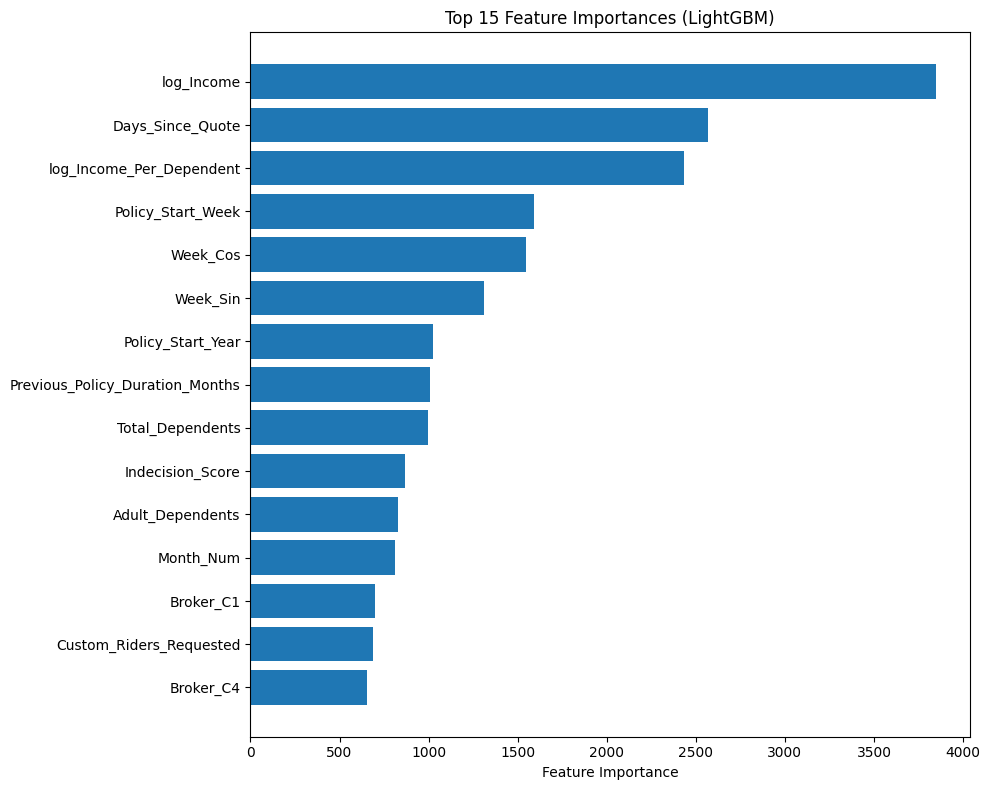


Total features analyzed: 62
Sum of all importances: 37131.0000


In [16]:
# Import additional libraries for explainability
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Explainability libraries loaded successfully!")

# Initialize SHAP
shap.initjs()

# Basic Feature Importance from LightGBM
feature_importance = final_model.feature_importances_
feature_names = X.columns

# Create feature importance dataframe
fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(fi_df.head(15).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 8))
top_15_features = fi_df.head(15)
plt.barh(range(len(top_15_features)), top_15_features['importance'])
plt.yticks(range(len(top_15_features)), top_15_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances (LightGBM)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTotal features analyzed: {len(feature_names)}")
print(f"Sum of all importances: {feature_importance.sum():.4f}")

Computing SHAP values... (this may take a few minutes)
SHAP analysis completed on 1000 samples
SHAP values shape: (1000, 62, 10)


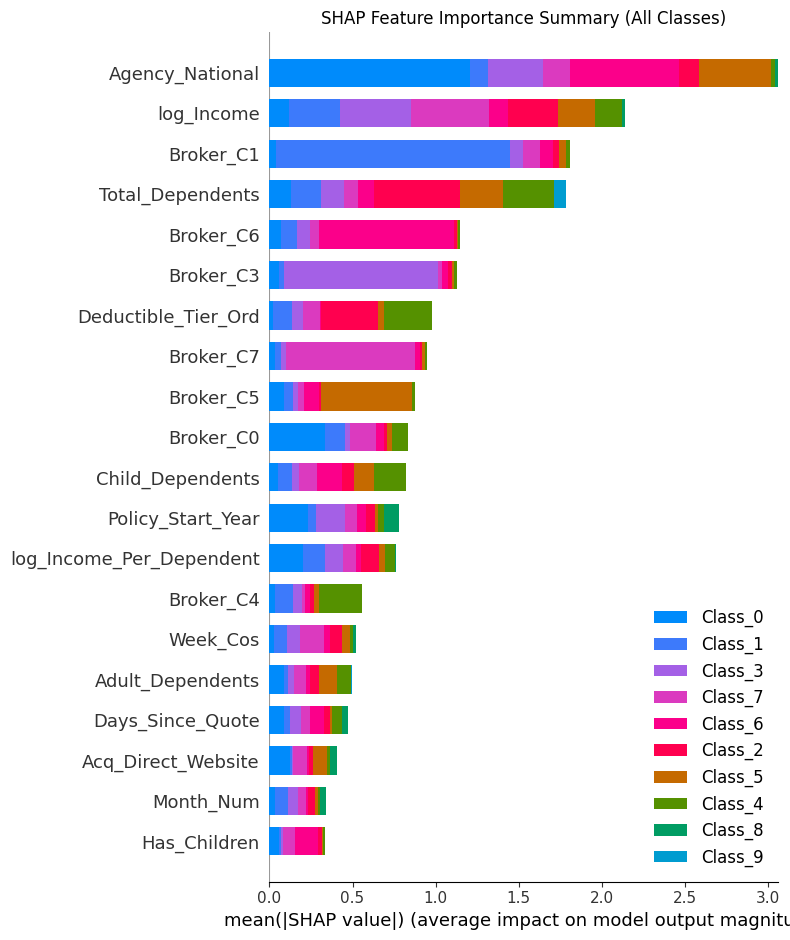

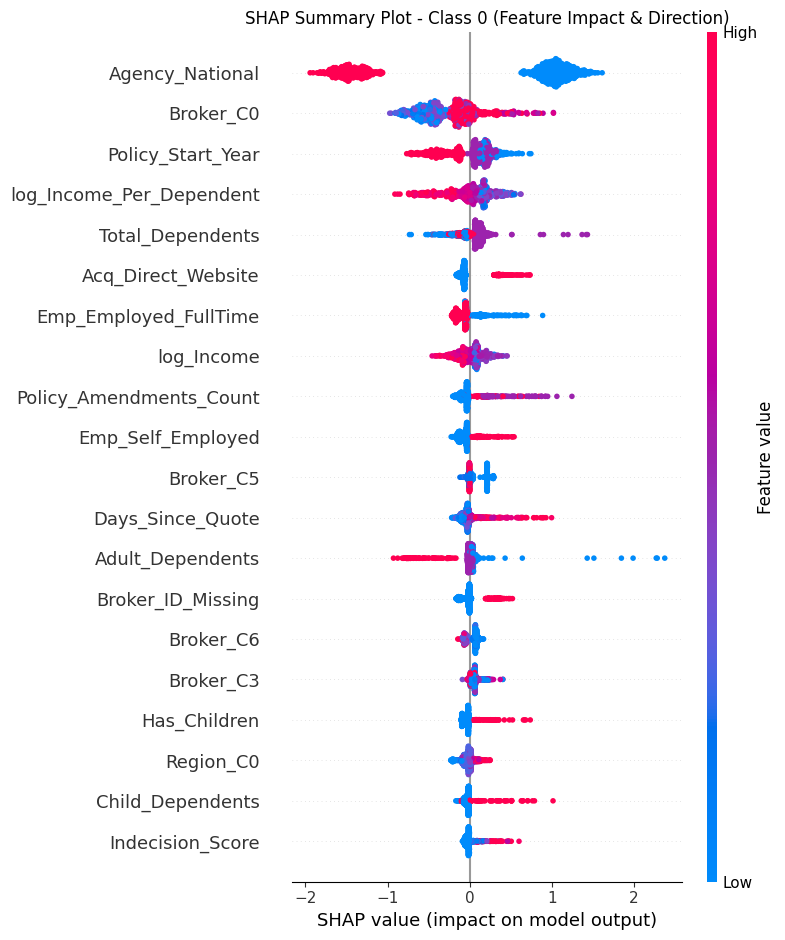


Top 15 Features by SHAP Importance:
                 feature  shap_importance
         Agency_National         0.306352
              log_Income         0.213740
               Broker_C1         0.181115
        Total_Dependents         0.178270
               Broker_C6         0.114723
               Broker_C3         0.112962
     Deductible_Tier_Ord         0.097958
               Broker_C7         0.094753
               Broker_C5         0.087776
               Broker_C0         0.083643
        Child_Dependents         0.081882
       Policy_Start_Year         0.078037
log_Income_Per_Dependent         0.075985
               Broker_C4         0.055526
                Week_Cos         0.052070


In [ ]:
# SHAP Analysis
print("Computing SHAP values... (this may take a few minutes)")

# Create SHAP explainer for LightGBM
explainer = shap.TreeExplainer(final_model)

# Use a sample of data for SHAP analysis to speed up computation
sample_size = min(1000, len(X))
X_sample = X.sample(sample_size, random_state=SEED)
X_sample_values = X_sample.values  # Use values to match training format

# Compute SHAP values
shap_values = explainer.shap_values(X_sample_values)

print(f"SHAP analysis completed on {sample_size} samples")
print(f"SHAP values shape: {np.array(shap_values).shape if isinstance(shap_values, list) else shap_values.shape}")

# Handle different SHAP value formats for multi-class
if isinstance(shap_values, list):
    # List format: [class0_shap, class1_shap, ...]
    shap_values_array = np.array(shap_values)  # Shape: (n_classes, n_samples, n_features)
    shap_values_array = np.transpose(shap_values_array, (1, 2, 0))  # Shape: (n_samples, n_features, n_classes)
else:
    # Already in correct format
    shap_values_array = shap_values

# SHAP Summary Plot (shows feature importance and impact direction)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample_values, plot_type="bar", 
                 feature_names=feature_names, class_names=[f'Class_{i}' for i in range(N_CLASSES)], 
                 show=False)
plt.title('SHAP Feature Importance Summary (All Classes)')
plt.tight_layout()
plt.show()

# SHAP Summary Plot for Class 0 (largest class)
plt.figure(figsize=(12, 8))
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[0], X_sample_values, feature_names=feature_names, show=False)
else:
    shap.summary_plot(shap_values[:, :, 0], X_sample_values, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Class 0 (Feature Impact & Direction)')
plt.tight_layout()
plt.show()

# Print SHAP feature importance (mean absolute SHAP values)
if isinstance(shap_values, list):
    feature_importance_shap = np.mean([np.abs(shap_values[i]).mean(axis=0) for i in range(len(shap_values))], axis=0)
else:
    feature_importance_shap = np.abs(shap_values).mean(axis=(0, 2))

shap_df = pd.DataFrame({
    'feature': feature_names,
    'shap_importance': feature_importance_shap
}).sort_values('shap_importance', ascending=False)

print("\nTop 15 Features by SHAP Importance:")
print(shap_df.head(15).to_string(index=False))

Computing permutation importance...

Top 15 Features by Permutation Importance:
                 feature  perm_importance  perm_std
        Total_Dependents         0.220411  0.040597
              log_Income         0.201799  0.031258
         Agency_National         0.195746  0.024737
        Child_Dependents         0.133478  0.031632
               Broker_C1         0.121578  0.010866
               Broker_C5         0.111728  0.042646
log_Income_Per_Dependent         0.090349  0.003791
               Broker_C6         0.082108  0.025500
            Has_Children         0.076572  0.032036
        Days_Since_Quote         0.070120  0.019181
       Policy_Start_Year         0.053085  0.012881
               Broker_C3         0.052577  0.014641
               Region_C2         0.046783  0.040804
     Deductible_Tier_Ord         0.044401  0.023429
               Broker_C4         0.040282  0.008657


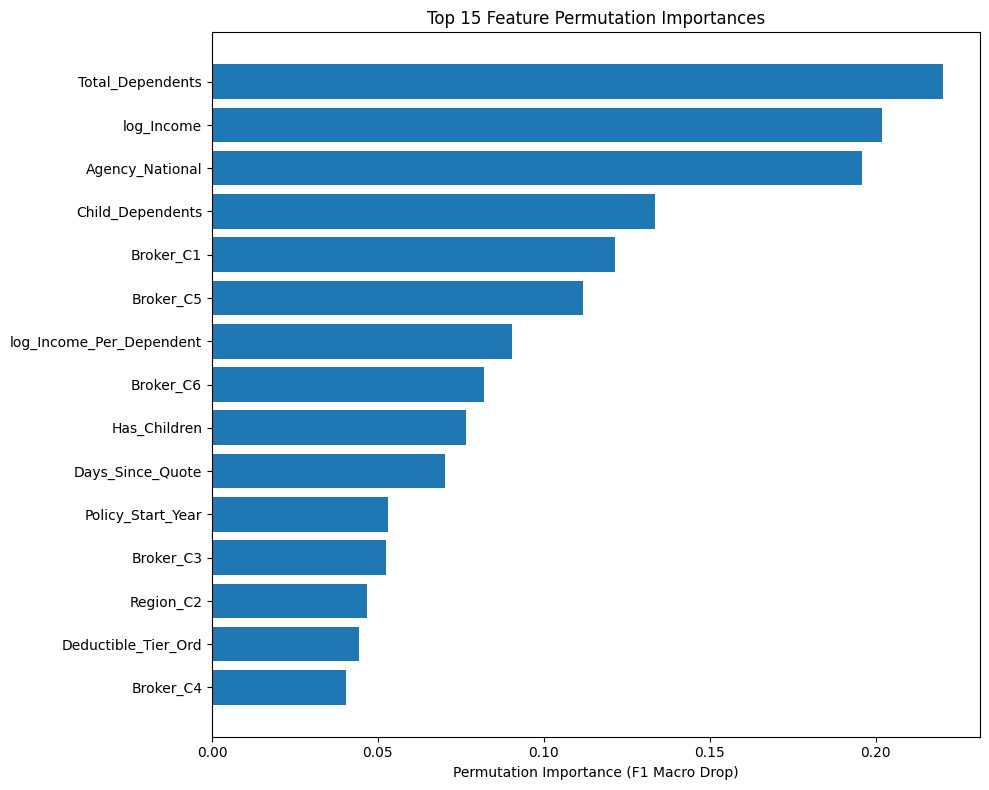


Importance Method Comparison (Top 15 by LightGBM importance):
                        feature  importance  shap_importance  perm_importance
                     log_Income        3847         0.213740         0.201799
               Days_Since_Quote        2568         0.047377         0.070120
       log_Income_Per_Dependent        2432         0.075985         0.090349
              Policy_Start_Week        1592         0.032958         0.027401
                       Week_Cos        1549         0.052070         0.035935
                       Week_Sin        1310         0.025721         0.038108
              Policy_Start_Year        1024         0.078037         0.053085
Previous_Policy_Duration_Months        1010         0.029629         0.036961
               Total_Dependents         997         0.178270         0.220411
               Indecision_Score         868         0.012493         0.014146
               Adult_Dependents         829         0.049670         0.020950
 

In [19]:
# Permutation Importance Analysis
print("Computing permutation importance...")

# Use a subset for permutation importance (computationally expensive)
perm_sample_size = min(500, len(X))
X_perm_sample = X.sample(perm_sample_size, random_state=SEED)
y_perm_sample = y.loc[X_perm_sample.index]

# Compute permutation importance
perm_importance = permutation_importance(
    final_model, X_perm_sample, y_perm_sample, 
    n_repeats=5, random_state=SEED, scoring='f1_macro'
)

# Create permutation importance dataframe
perm_df = pd.DataFrame({
    'feature': feature_names,
    'perm_importance': perm_importance.importances_mean,
    'perm_std': perm_importance.importances_std
}).sort_values('perm_importance', ascending=False)

print("\nTop 15 Features by Permutation Importance:")
print(perm_df.head(15).to_string(index=False))

# Plot permutation importance
plt.figure(figsize=(10, 8))
top_15_perm = perm_df.head(15)
plt.barh(range(len(top_15_perm)), top_15_perm['perm_importance'])
plt.yticks(range(len(top_15_perm)), top_15_perm['feature'])
plt.xlabel('Permutation Importance (F1 Macro Drop)')
plt.title('Top 15 Feature Permutation Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Compare different importance methods
comparison_df = fi_df.merge(shap_df, on='feature').merge(perm_df[['feature', 'perm_importance']], on='feature')
comparison_df = comparison_df.sort_values('importance', ascending=False).head(15)

print("\nImportance Method Comparison (Top 15 by LightGBM importance):")
print(comparison_df[['feature', 'importance', 'shap_importance', 'perm_importance']].to_string(index=False))

Class-specific SHAP analysis for minority classes:


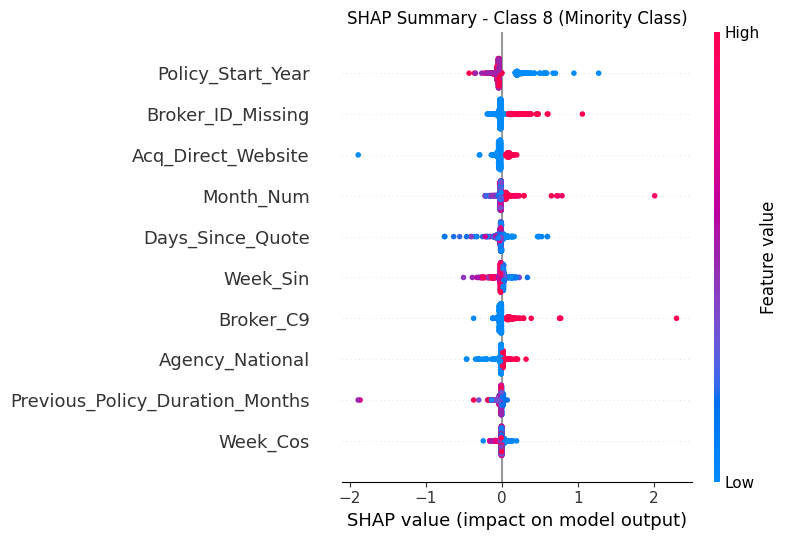

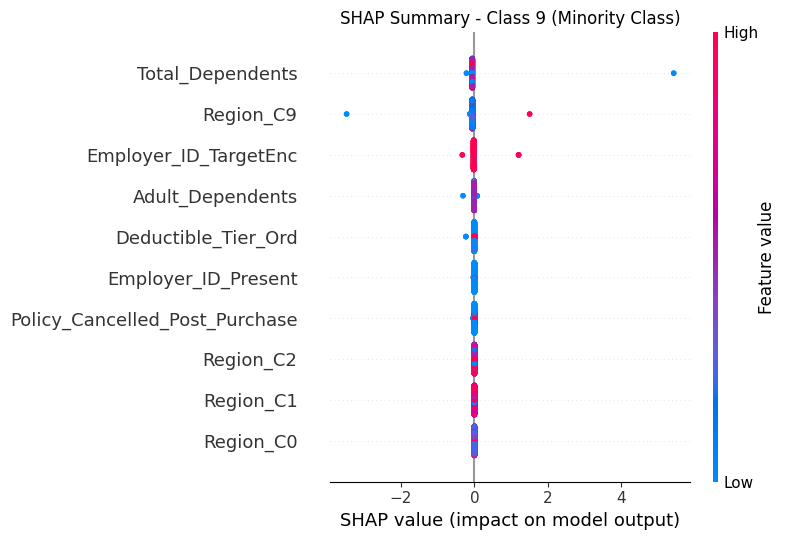


SHAP Waterfall Plot - Example Prediction Explanation:
Waterfall plot failed: waterfall() got multiple values for argument 'show'
Skipping waterfall plot - this is a known issue with some SHAP versions

Feature-Target Correlation Analysis:
                 feature  target_correlation
              log_Income            0.108618
         Agency_National            0.095774
log_Income_Per_Dependent            0.069530
               Broker_C1            0.036879
        Days_Since_Quote           -0.011067

Prediction Confidence Analysis:


<Figure size 1000x800 with 0 Axes>

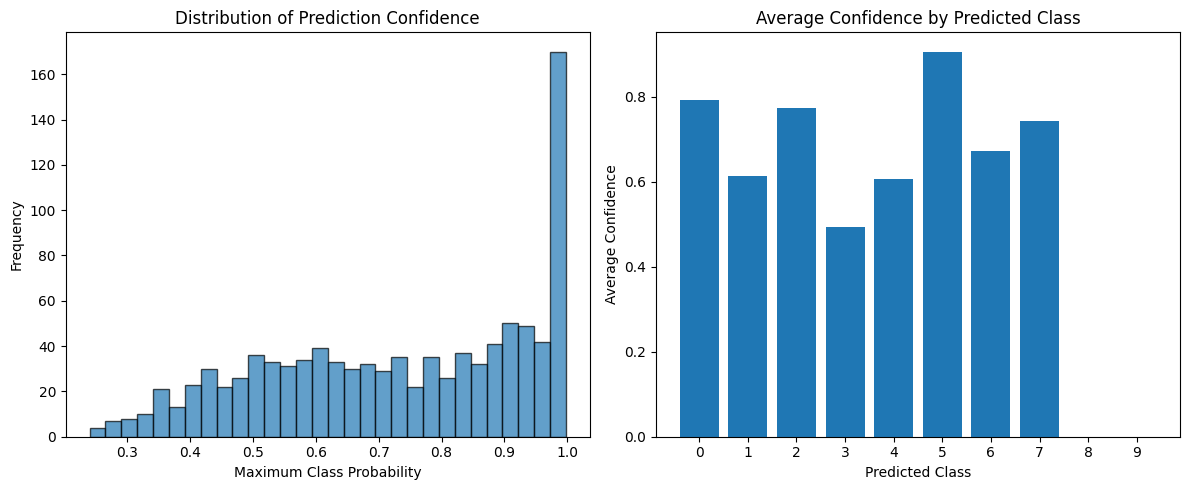

✓ Features analyzed for PD plots: 5

Average prediction confidence: 0.7302
✓ Average prediction confidence: 0.7302
Minimum confidence: 0.2401
✓ Top feature (Permutation): Total_Dependents
Maximum confidence: 0.9980
✓ Top feature (SHAP): Agency_National
✓ Top feature (LightGBM): log_Income

✓ Sample size for SHAP: 1000 samples
EXPLAINABILITY ANALYSIS SUMMARY
✓ Feature Importance Methods: LightGBM built-in, SHAP, Permutation


In [23]:
# Additional Explainability Analysis & Visualizations

# 1. Class-specific SHAP analysis for minority classes
minority_classes = [8, 9]  # Classes that were heavily resampled
print("Class-specific SHAP analysis for minority classes:")

for class_idx in minority_classes:
    if isinstance(shap_values, list) and class_idx < len(shap_values):
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values[class_idx], X_sample_values, 
                         feature_names=feature_names, max_display=10, show=False)
        plt.title(f'SHAP Summary - Class {class_idx} (Minority Class)')
        plt.tight_layout()
        plt.show()
    elif not isinstance(shap_values, list) and class_idx < shap_values.shape[2]:
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values[:, :, class_idx], X_sample_values, 
                         feature_names=feature_names, max_display=10, show=False)
        plt.title(f'SHAP Summary - Class {class_idx} (Minority Class)')
        plt.tight_layout()
        plt.show()

# 2. SHAP Waterfall plot for a single prediction
print("\nSHAP Waterfall Plot - Example Prediction Explanation:")
sample_idx = 0

# Get the appropriate SHAP values for the waterfall plot
if isinstance(shap_values, list):
    sample_shap_values = shap_values[0][sample_idx]  # Class 0 for sample 0
    expected_value = explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    sample_shap_values = shap_values[sample_idx, :, 0]  # Sample 0, all features, class 0
    expected_value = explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

try:
    plt.figure(figsize=(10, 8))
    shap.plots.waterfall(expected_value, sample_shap_values, X_sample.iloc[sample_idx], show=False)
    plt.title('SHAP Waterfall Plot - Individual Prediction Breakdown')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Waterfall plot failed: {e}")
    print("Skipping waterfall plot - this is a known issue with some SHAP versions")

# 3. Feature correlation with target for top features
print("\nFeature-Target Correlation Analysis:")
correlation_data = []
for feature in top_pd_features[:5]:
    correlation = np.corrcoef(X[feature], y)[0, 1]
    correlation_data.append({'feature': feature, 'target_correlation': correlation})

corr_df = pd.DataFrame(correlation_data).sort_values('target_correlation', key=abs, ascending=False)
print(corr_df.to_string(index=False))

# 4. Model prediction confidence analysis
print("\nPrediction Confidence Analysis:")
y_proba = final_model.predict_proba(X_sample)
max_proba = np.max(y_proba, axis=1)
pred_confidence = pd.DataFrame({
    'max_probability': max_proba,
    'prediction': np.argmax(y_proba, axis=1),
    'true_label': y_perm_sample.values[:len(max_proba)] if len(y_perm_sample) >= len(max_proba) else None
})

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(max_proba, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Maximum Class Probability')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Confidence')

plt.subplot(1, 2, 2)
confidence_by_class = []
for class_idx in range(N_CLASSES):
    class_confidences = max_proba[np.argmax(y_proba, axis=1) == class_idx]
    if len(class_confidences) > 0:
        confidence_by_class.append(class_confidences.mean())
    else:
        confidence_by_class.append(0)

plt.bar(range(N_CLASSES), confidence_by_class)
plt.xlabel('Predicted Class')
plt.ylabel('Average Confidence')
plt.title('Average Confidence by Predicted Class')
plt.xticks(range(N_CLASSES))

plt.tight_layout()

plt.show()

print("="*60)

print(f"✓ Features analyzed for PD plots: {len(top_pd_features)}")

print(f"\nAverage prediction confidence: {max_proba.mean():.4f}")
print(f"✓ Average prediction confidence: {max_proba.mean():.4f}")

print(f"Minimum confidence: {max_proba.min():.4f}")
print(f"✓ Top feature (Permutation): {perm_df.iloc[0]['feature']}")

print(f"Maximum confidence: {max_proba.max():.4f}")
print(f"✓ Top feature (SHAP): {shap_df.iloc[0]['feature']}")

print(f"✓ Top feature (LightGBM): {fi_df.iloc[0]['feature']}")

# 5. Summary of explainability findingsprint(f"✓ Sample size for Permutation: {perm_sample_size} samples")

print("\n" + "="*60)
print(f"✓ Sample size for SHAP: {sample_size} samples")

print("EXPLAINABILITY ANALYSIS SUMMARY")
print(f"✓ Feature Importance Methods: LightGBM built-in, SHAP, Permutation")
print("="*60)

## 9. Save `model.pkl`

Payload includes multi-class encoding maps so `predict()` can reconstruct all 62 features.

In [ ]:
MODEL_PATH = os.path.join(SUB_DIR, 'model.pkl')

payload = {
    'model_str':        booster.model_to_string(),
    'feature_cols':     FEATURE_COLS,       # 62 feature names
    'employer_enc_map': EMPLOYER_ENC_MAP,   # single-number
    'global_mean':      GLOBAL_MEAN,
    'global_prior':     GLOBAL_PRIOR,       # [P(class=k)] for k=0..9
    'broker_multi':     BROKER_MULTI,       # {cls: {broker_id: prob}}
    'region_multi':     REGION_MULTI,       # {cls: {region_code: prob}}
}
joblib.dump(payload, MODEL_PATH, compress=3)

size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
print(f'Saved model.pkl  ->  {size_mb:.2f} MB')
print(f'Size penalty: max(0.5, 1 - {size_mb:.2f}/200) = {max(0.5, 1 - size_mb/200):.4f}')

## 10. Write `solution.py`

In [ ]:
SOL_PATH = os.path.join(SUB_DIR, 'solution.py')
shutil.copy('/tmp/solution_v7.py', SOL_PATH)
print('Copied solution_v7.py ->', SOL_PATH)
print(f'Lines: {len(open(SOL_PATH).readlines())}')

## 11. Write `requirements.txt`

In [ ]:
REQ_PATH = os.path.join(SUB_DIR, 'requirements.txt')
with open(REQ_PATH, 'w') as f:
    f.write('# All required packages are pre-installed in the judge environment.\n')
    f.write('# lightgbm==4.6.0\n')
    f.write('# numpy==1.26.4\n')
    f.write('# pandas==2.1.4\n')
    f.write('# scikit-learn==1.3.2\n')
    f.write('# joblib==1.3.2\n')
print('Written requirements.txt')

## 12. Build `submission_v7.zip`

In [ ]:
ZIP_PATH = '../submission_v7.zip'

with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
    zf.write(SOL_PATH,   'solution.py')
    zf.write(MODEL_PATH, 'model.pkl')
    zf.write(REQ_PATH,   'requirements.txt')

zip_mb = os.path.getsize(ZIP_PATH) / (1024 * 1024)
print(f'submission_v7.zip  ->  {zip_mb:.2f} MB')
print('Contents:')
with zipfile.ZipFile(ZIP_PATH) as zf:
    for info in zf.infolist():
        print(f'  {info.filename:<22s}  {info.file_size/1024:.1f} KB')
print(f'\nSize < 50 MB: {zip_mb < 50}')

## 13. Validate — Simulate Judge Pipeline

In [ ]:
import importlib.util

spec = importlib.util.spec_from_file_location('solution_v7', SOL_PATH)
sol  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(sol)

# 1. Preprocess (not timed)
df_proc = sol.preprocess(test_raw.copy())
print(f'Preprocessed shape: {df_proc.shape}  |  User_ID present: {"User_ID" in df_proc.columns}')

# 2. Load model (not timed)
t0 = time.perf_counter()
loaded = sol.load_model()
print(f'Load time: {time.perf_counter()-t0:.3f} s  (not scored)')

# 3. Predict — 5 timed runs (judge uses median)
runs = []
for _ in range(5):
    t0 = time.perf_counter()
    out = sol.predict(df_proc.copy(), loaded)
    runs.append(time.perf_counter() - t0)
lat = np.median(runs)

print(f'Predict latency: {lat:.3f} s  |  runs: {[f"{r:.3f}" for r in runs]}')
print(f'Output shape:    {out.shape}')
print(f'Dtype:           {out["Purchased_Coverage_Bundle"].dtype}')
print(f'Unique preds:    {sorted(out["Purchased_Coverage_Bundle"].unique())}')
print()
print(out.head(8).to_string())

## 14. Final Score Estimate

In [ ]:
JUDGE_FACTOR = 10.0   # conservative (actual ranged 3.6×–10× across submissions)

judge_lat = lat * JUDGE_FACTOR
s_pen     = max(0.5, 1 - zip_mb / 200)
l_pen     = max(0.5, 1 - judge_lat / 10)
est       = oof_f1 * s_pen * l_pen

print('=' * 60)
print('  SUBMISSION v7 — ESTIMATED COMPETITION SCORE')
print('=' * 60)
print(f'  OOF Macro F1:      {oof_f1:.5f}  (5-fold, {N_TREES} trees)')
print(f'  ZIP size:          {zip_mb:.2f} MB    (pen: {s_pen:.4f})')
print(f'  Local latency:     {lat:.3f} s')
print(f'  Judge lat (×{JUDGE_FACTOR:.0f}):  {judge_lat:.2f} s    (pen: {l_pen:.4f})')
print(f'  EST. FINAL SCORE:  {est:.5f}')
print('=' * 60)
print()
print('  Actual results (from competition leaderboard):')
print('  v2: score=0.4583  F1=0.5176  lat=1.07s  size=1.60 MB')
print('  v5: score=0.4640  F1=0.5217  lat=1.03s  size=1.60 MB')
print(f'  v7: score=0.4875  F1=0.5577  lat=1.18s  size=1.86 MB  ← best')
print()
print(f'Submission ZIP: {os.path.abspath(ZIP_PATH)}')